In [1]:
import matplotlib.pyplot as plt
import pathlib, os, random
import numpy as np
import pandas as pd
import tensorflow as tf
import keras


from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Activation, BatchNormalization, Dropout , GlobalAveragePooling2D
from keras.preprocessing.image import ImageDataGenerator
from keras import Sequential
from keras.callbacks import Callback, EarlyStopping,ModelCheckpoint

In [2]:
train_path="C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\various split\\7030\\train\\"
no_birds_classes = os.listdir(train_path)
len(no_birds_classes)

41

In [3]:
data_dir = pathlib.Path("C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\various split\\7030\\train\\")
BirdClasses = np.array(([item.name for item in data_dir.glob("*")]))
print(BirdClasses)

['babblers bird' 'barbets bird' 'bulbuls bird' 'coots bird' 'cranes bird'
 'cuckoos bird' 'Doves bird' 'Drongos bird' 'Ducks bird' 'Eagles bird'
 'Egrets bird' 'Falcons bird' 'Finches bird' 'Flycatchers bird'
 'Herons bird' 'Hornbills bird' 'Jacanas bird' 'kingfishers bird'
 'munias bird' 'nightjars bird' 'orioles bird' 'owls bird'
 'parakeets bird' 'peafowl bird' 'pesants bird' 'pigeons bird'
 'plovers bird' 'prinias bird' 'robins bird' 'sandpipers bird'
 'shrikes bird' 'storks bird' 'sunbirds bird' 'swallows bird'
 'swamphens bird' 'swifts bird' 'terns bird' 'tits bird' 'wagtails bird'
 'warblers bird' 'woodpeckers bird']


# visualising the images

In [4]:
def view_random_image(target_dir, target_class):
  
  # setting up the image directory
  target_folder = target_dir +'\\' + target_class

  #get a random image path
  random_image = random.sample(os.listdir(target_folder), 1)

  #read image and plotting it
  img = plt.imread(target_folder + "\\" + random_image[0] )
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off")

  #print(f"Image shape: {img.shape}")
  
  return img

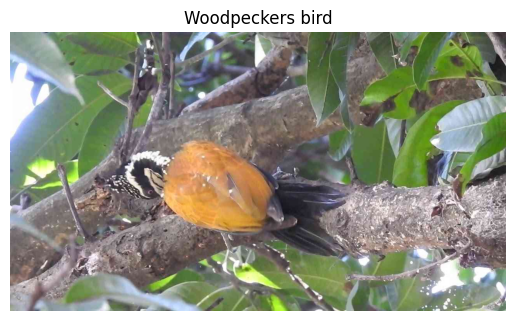

In [5]:
img = view_random_image(train_path,'Woodpeckers bird')

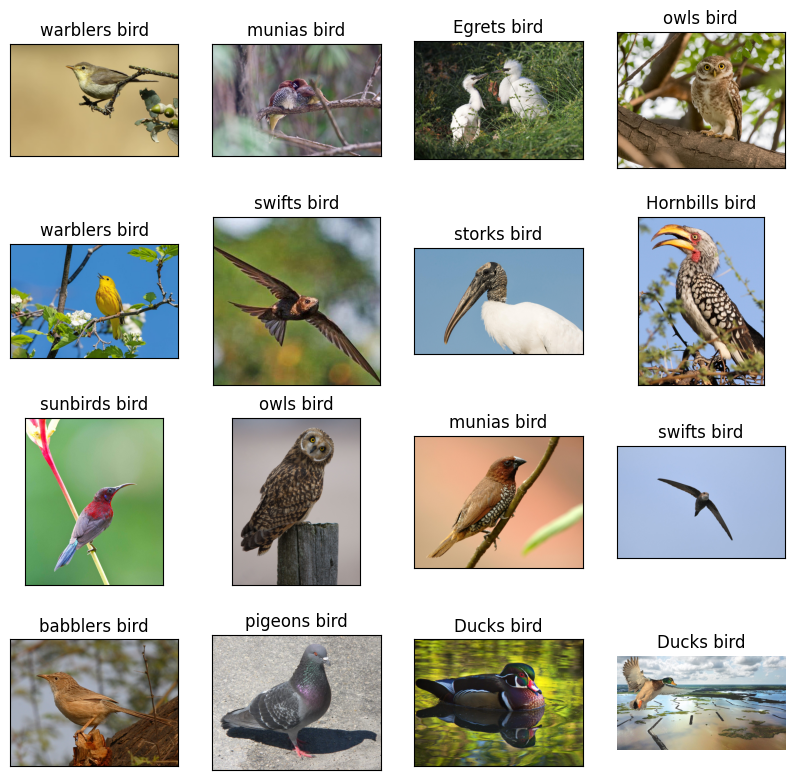

In [6]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 10),
                        subplot_kw={'xticks': [], 'yticks': []})

random_index = np.random.randint(0 , len(BirdClasses)-1 , 16)

for i, ax in enumerate(axes.flat):
    ax.imshow(view_random_image(train_path,BirdClasses[random_index[i]]))
    ax.set_title(BirdClasses[random_index[i]])

# data preprocessing 

In [7]:
train_dir ="C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\various split\\7030\\train\\"
test_dir ="C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\various split\\7030\\test\\"
val_dir ="C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\various split\\7030\\val\\"

In [8]:
from keras.applications.mobilenet_v2 import MobileNetV2

In [9]:
train_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory( train_dir , target_size=(224,224) , batch_size=32 , class_mode = "categorical" ,shuffle=True )

val_data = val_gen.flow_from_directory( val_dir , target_size=(224,224) , batch_size=32 , class_mode = "categorical" , shuffle=True )

test_data = test_gen.flow_from_directory( test_dir , target_size=(224,224) , batch_size=32 , class_mode = "categorical" ,shuffle=False )

Found 4303 images belonging to 41 classes.
Found 902 images belonging to 41 classes.
Found 942 images belonging to 41 classes.


# Preparing MobileNet Pretrained Model

In [10]:
mobilenet = tf.keras.applications.inception_v3.InceptionV3( include_top=False , weights="imagenet" , input_shape=(224,224,3))

mobilenet.summary()

Model: "inception_v3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 111, 111, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 111, 111, 32  96         ['conv2d[0][0]']                 
 alization)                     )                                                      

 block2a_project_conv (Conv2D)  (None, 56, 56, 64)   8192        ['block2a_expand_activation[0][0]
                                                                 ']                               
                                                                                                  
 block2a_project_bn (BatchNorma  (None, 56, 56, 64)  256         ['block2a_project_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 block2b_expand_conv (Conv2D)   (None, 56, 56, 256)  147456      ['block2a_project_bn[0][0]']     
                                                                                                  
 block2b_expand_bn (BatchNormal  (None, 56, 56, 256)  1024       ['block2b_expand_conv[0][0]']    
 ization)                                                                                         
          

                                                                                                  
 block2f_expand_bn (BatchNormal  (None, 56, 56, 256)  1024       ['block2f_expand_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 block2f_expand_activation (Act  (None, 56, 56, 256)  0          ['block2f_expand_bn[0][0]']      
 ivation)                                                                                         
                                                                                                  
 block2f_project_conv (Conv2D)  (None, 56, 56, 64)   16384       ['block2f_expand_activation[0][0]
                                                                 ']                               
                                                                                                  
 block2f_p

                                                                                                  
 block3c_drop (Dropout)         (None, 28, 28, 96)   0           ['block3c_project_bn[0][0]']     
                                                                                                  
 block3c_add (Add)              (None, 28, 28, 96)   0           ['block3c_drop[0][0]',           
                                                                  'block3b_add[0][0]']            
                                                                                                  
 block3d_expand_conv (Conv2D)   (None, 28, 28, 384)  331776      ['block3c_add[0][0]']            
                                                                                                  
 block3d_expand_bn (BatchNormal  (None, 28, 28, 384)  1536       ['block3d_expand_conv[0][0]']    
 ization)                                                                                         
          

                                                                                                  
 block4a_expand_bn (BatchNormal  (None, 28, 28, 384)  1536       ['block4a_expand_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 block4a_expand_activation (Act  (None, 28, 28, 384)  0          ['block4a_expand_bn[0][0]']      
 ivation)                                                                                         
                                                                                                  
 block4a_dwconv2 (DepthwiseConv  (None, 14, 14, 384)  3456       ['block4a_expand_activation[0][0]
 2D)                                                             ']                               
                                                                                                  
 block4a_b

...

                                                                                                  
 block6w_expand_conv (Conv2D)   (None, 7, 7, 2304)   884736      ['block6v_add[0][0]']            
                                                                                                  
 block6w_expand_bn (BatchNormal  (None, 7, 7, 2304)  9216        ['block6w_expand_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 block6w_expand_activation (Act  (None, 7, 7, 2304)  0           ['block6w_expand_bn[0][0]']      
 ivation)                                                                                         
                                                                                                  
 block6w_dwconv2 (DepthwiseConv  (None, 7, 7, 2304)  20736       ['block6w_expand_activation[0][0]
 2D)      

                                                                                                  
 block6y_expand_activation (Act  (None, 7, 7, 2304)  0           ['block6y_expand_bn[0][0]']      
 ivation)                                                                                         
                                                                                                  
 block6y_dwconv2 (DepthwiseConv  (None, 7, 7, 2304)  20736       ['block6y_expand_activation[0][0]
 2D)                                                             ']                               
                                                                                                  
 block6y_bn (BatchNormalization  (None, 7, 7, 2304)  9216        ['block6y_dwconv2[0][0]']        
 )                                                                                                
                                                                                                  
 block6y_a

 block7b_activation (Activation  (None, 7, 7, 3840)  0           ['block7b_bn[0][0]']             
 )                                                                                                
                                                                                                  
 block7b_se_squeeze (GlobalAver  (None, 3840)        0           ['block7b_activation[0][0]']     
 agePooling2D)                                                                                    
                                                                                                  
 block7b_se_reshape (Reshape)   (None, 1, 1, 3840)   0           ['block7b_se_squeeze[0][0]']     
                                                                                                  
 block7b_se_reduce (Conv2D)     (None, 1, 1, 160)    614560      ['block7b_se_reshape[0][0]']     
                                                                                                  
 block7b_s

                                                                                                  
 block7d_se_reshape (Reshape)   (None, 1, 1, 3840)   0           ['block7d_se_squeeze[0][0]']     
                                                                                                  
 block7d_se_reduce (Conv2D)     (None, 1, 1, 160)    614560      ['block7d_se_reshape[0][0]']     
                                                                                                  
 block7d_se_expand (Conv2D)     (None, 1, 1, 3840)   618240      ['block7d_se_reduce[0][0]']      
                                                                                                  
 block7d_se_excite (Multiply)   (None, 7, 7, 3840)   0           ['block7d_activation[0][0]',     
                                                                  'block7d_se_expand[0][0]']      
                                                                                                  
 block7d_p

 block7f_se_expand (Conv2D)     (None, 1, 1, 3840)   618240      ['block7f_se_reduce[0][0]']      
                                                                                                  
 block7f_se_excite (Multiply)   (None, 7, 7, 3840)   0           ['block7f_activation[0][0]',     
                                                                  'block7f_se_expand[0][0]']      
                                                                                                  
 block7f_project_conv (Conv2D)  (None, 7, 7, 640)    2457600     ['block7f_se_excite[0][0]']      
                                                                                                  
 block7f_project_bn (BatchNorma  (None, 7, 7, 640)   2560        ['block7f_project_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 block7f_d

# Fine-Tuning MobileNet Model

In [11]:
# Freezing all layers except the last 20 layers

mobilenet.trainable=True
"""
for layer in mobilenet.layers[:-20]:
  layer.trainable=False
"""

'\nfor layer in mobilenet.layers[:-20]:\n  layer.trainable=False\n'

In [12]:
Model = Sequential([
    mobilenet,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(256,activation='relu'),
    BatchNormalization(),
    Dense(41,activation='softmax')
])

Model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_v3 (Functional)   (None, 5, 5, 2048)        21802784  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization_94 (Bat  (None, 2048)             8192      
 chNormalization)                                                
                                                                 
 dense (Dense)               (None, 256)               524544    
                                                                 
 batch_normalization_95 (Bat  (None, 256)              1024      
 chNormalization)                                                
                                                        

In [13]:
#Model.compile( optimizer="adam", loss="categorical_crossentropy" , metrics=["accuracy"] )
Model.compile(optimizer = keras.optimizers.SGD(learning_rate=0.001, decay=1e-6, momentum=0.9, nesterov=True),
               loss = 'categorical_crossentropy',
              metrics = ['accuracy'])

In [14]:
# Create Callback Checkpoint

#checkpoint_path = "BirdsSpecies_Model_Checkpoint"
#checkpoint_callback = ModelCheckpoint(checkpoint_path,monitor="val_accuracy",save_best_only=True)

callbacks = [EarlyStopping(monitor='val_accuracy' , patience=5 , restore_best_weights=True)]

In [15]:
history = Model.fit(train_data,epochs=35,batch_size=32 ,steps_per_epoch = len(train_data)
,callbacks=callbacks , validation_data=val_data,validation_steps = len(val_data))

Epoch 1/35
135/135 [==============================] - 162s 1s/step - loss: 1.9602 - accuracy: 0.5001 - val_loss: 1.5315 - val_accuracy: 0.6109
Epoch 2/35
135/135 [==============================] - 133s 981ms/step - loss: 0.5032 - accuracy: 0.8682 - val_loss: 0.9313 - val_accuracy: 0.7572
Epoch 3/35
135/135 [==============================] - 133s 974ms/step - loss: 0.1512 - accuracy: 0.9770 - val_loss: 0.7914 - val_accuracy: 0.7894
Epoch 4/35
135/135 [==============================] - 133s 978ms/step - loss: 0.0647 - accuracy: 0.9947 - val_loss: 0.7531 - val_accuracy: 0.8049
Epoch 5/35
135/135 [==============================] - 132s 978ms/step - loss: 0.0359 - accuracy: 0.9986 - val_loss: 0.7434 - val_accuracy: 0.7938
Epoch 6/35
135/135 [==============================] - 133s 984ms/step - loss: 0.0282 - accuracy: 0.9995 - val_loss: 0.7259 - val_accuracy: 0.7993
Epoch 7/35
135/135 [==============================] - 133s 986ms/step - loss: 0.0237 - accuracy: 0.9991 - val_loss: 0.7321 - va

In [16]:
Model.save("inception_7030.h5")

In [17]:
test_gen = ImageDataGenerator(rescale=1./255)
test_data = test_gen.flow_from_directory( test_dir , target_size=(224,224) , batch_size=1 , class_mode = "categorical" ,shuffle=False )
filenames = test_data.filenames
nb_samples = len(filenames)

prediction = Model.predict(test_data ,steps = nb_samples)

Found 942 images belonging to 41 classes.
942/942 [==============================] - 34s 34ms/step


In [18]:
from sklearn.metrics import classification_report, confusion_matrix


y_pred = np.argmax(prediction, axis=1)
#y_pred=np.asarray(prediction)
print('Confusion Matrix')
print(confusion_matrix(test_data.classes, y_pred))
print('Classification Report')
target_names =BirdClasses  
print(classification_report(test_data.classes, y_pred, target_names=BirdClasses))


Confusion Matrix
[[16  0  1 ...  0  0  0]
 [ 0 21  0 ...  0  0  0]
 [ 0  0 19 ...  0  0  0]
 ...
 [ 0  1  0 ... 21  0  0]
 [ 0  0  0 ...  0 16  0]
 [ 0  0  0 ...  0  1 18]]
Classification Report
                  precision    recall  f1-score   support

   babblers bird       0.73      0.70      0.71        23
    barbets bird       0.84      0.91      0.88        23
    bulbuls bird       0.95      0.83      0.88        23
      coots bird       0.89      0.70      0.78        23
     cranes bird       0.69      0.87      0.77        23
    cuckoos bird       0.64      0.70      0.67        23
      Doves bird       0.63      0.52      0.57        23
    Drongos bird       0.71      0.74      0.72        23
      Ducks bird       0.81      0.74      0.77        23
     Eagles bird       0.87      0.87      0.87        23
     Egrets bird       0.78      0.91      0.84        23
    Falcons bird       0.54      0.61      0.57        23
    Finches bird       0.79      0.83      0.81   

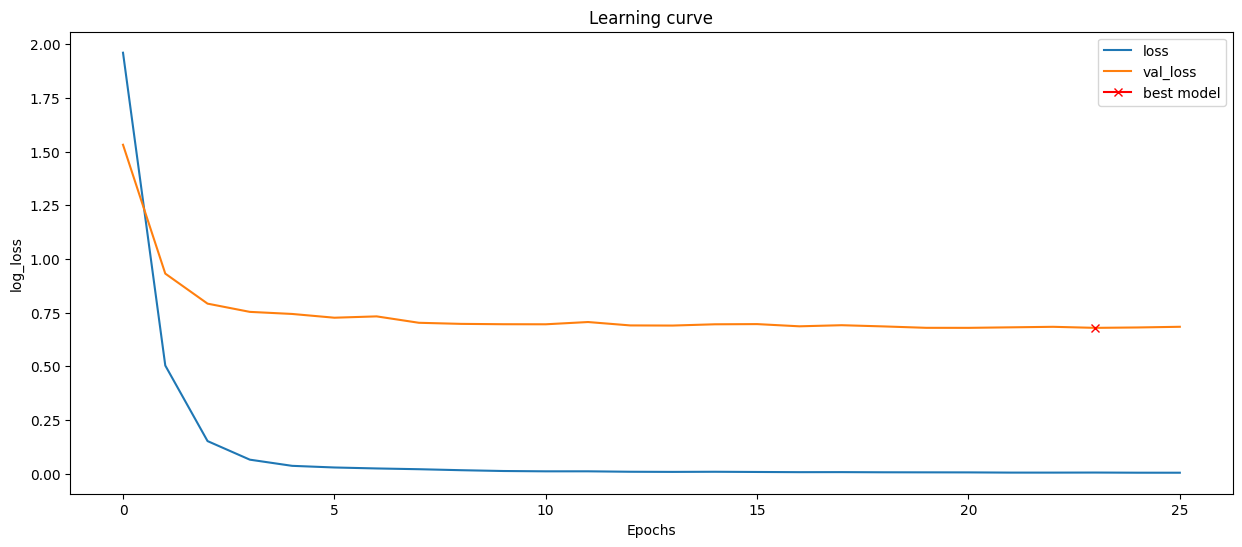

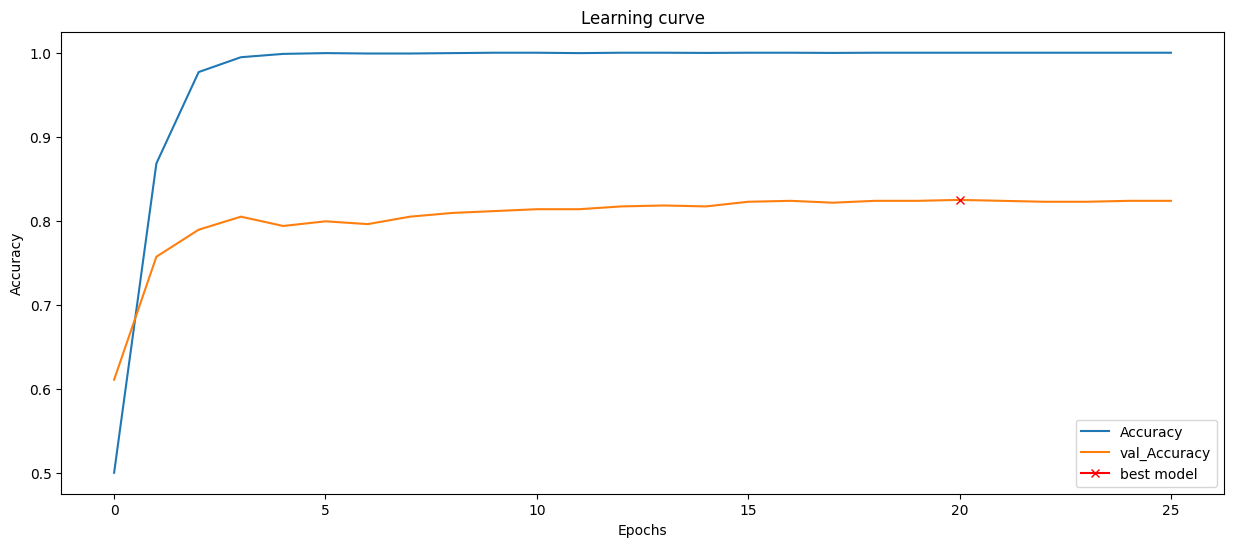

In [19]:
plt.figure(figsize = (15,6))
plt.title("Learning curve")
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.plot(np.argmin(history.history["val_loss"]), np.min(history.history["val_loss"]), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("log_loss")
plt.legend();

plt.figure(figsize = (15,6))
plt.title("Learning curve")
plt.plot(history.history["accuracy"], label="Accuracy")
plt.plot(history.history["val_accuracy"], label="val_Accuracy")
plt.plot(np.argmax(history.history["val_accuracy"]), np.max(history.history["val_accuracy"]), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend();
